In [1]:
import os
import numpy as np
import pandas as pd

# Checks directory exists
image_directory = './images'
if not os.path.exists(image_directory):
    print("Warning: {image_directory} directory not found.")

Imports any necessary libraries and makes sure that the directory exists (error handling percaution).

In [2]:
def pgm_to_csv(student_id, label, index):

    #follow naming specifications
    input_filename = f"{student_id}_{label}_{index:02d}.pgm"
    output_filename = f"{student_id}_{label}_{index:02d}.csv"

    input_path = os.path.join(image_directory, input_filename)
    output_path = os.path.join(image_directory, output_filename)

    try:
        with open(input_path, 'r') as f:
            lines = f.readlines()

        #Filter Comments
        data = [line.strip() for line in lines if not line.startswith('#')]

        #Skips PGM header & adds contents into 'pixels'
        pixel_strings = []
        for line in data[3:]:
            pixel_strings.extend(line.split())

        pixels_int = np.array([int(p) for p in pixel_strings])
        #pixels filtered into 1 or 0
        bool_mask = (pixels_int < 128)
        binary_matrix = bool_mask.astype(int).reshape(45, 45)

        #Saves and error handles
        np.savetxt(output_path, binary_matrix, delimiter=",", fmt='%d')
        return True
    except FileNotFoundError:
        return False

<h1>pgm_to_csv function explained</h1>

1. Takes two strings and inserts variables, giving what input and output file should look like (making sure to follow naming specifications). 

2. Code opens file and grabs every file line and places them into a list of strings. 

3. List is then cleaned to filter any comments and '/n' characters out. 

4. First three lines of PGM are skipped to avoid headers of file (Name, Gimp veriosn, Image size) and breaks the line of text into individual words.  

5. Strings are converted into integers for comparison

6. Using a Boolean Mask any pixels less then 128 are converetd to a 'True' and any pixels greater to a 'False'. The Binary-Matrix converts 'True to '1' and 'False' to '0' and places it in a 45 by 45 matrix.

7. 45 by 45 Grid is written to a CSV file (output_path). Code is written so that python saves integers (not decimals) and if all successful returns true.

8. Function returns false if the file cannot be found.

In [3]:
#Object labels
living_objects = ['cherry', 'banana', 'lemon', 'tree']
non_living_objects = ['envelope','golfclub','pencil','wineglass']
all_objects = living_objects + non_living_objects

#Variables
student_id = "40443014"
image_directory = "./images"
success_count = 0

#Main conversion loop
for objects in all_objects:
    for i in range(1,15):
        if pgm_to_csv(student_id, objects, i):
            success_count += 1

print(f"Finished, All {success_count} out of 112 images have been processed into a csv file.")

Finished, All 112 out of 112 images have been processed into a csv file.


<h1>Conversion Block</h1>

1. creates two different lists for living and non-living objects and created an 'all-objects' list that contains all.

2. Variables allows python to find specific file and look for image folder (also created a success count for validation of all images being changed to csv)

3. Loop picks one object at a time and runs through all 14 images then moves onto the next object.

4. Withing the inner loop the pgm_to_csv file is called and if it runs sucessfully success_count goes up by 1.

5. Code ends by printing verification that all images have been changed

Matrix Shape: (45, 45)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 

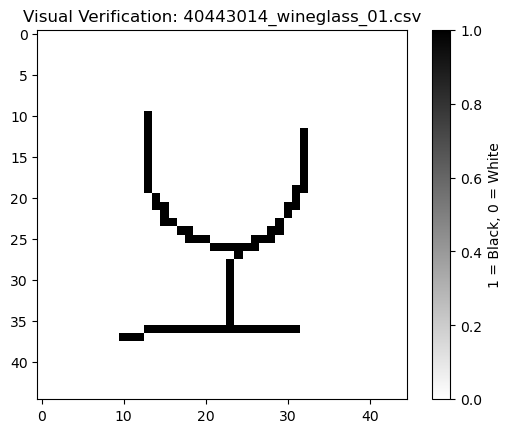

In [4]:
#Testing block

import matplotlib.pyplot as plt

#Force NumPy to print full matrix 
np.set_printoptions(threshold=np.inf, linewidth=np.inf)
#picking specific file far down image list to test
test_file = os.path.join(image_directory, f"{student_id}_wineglass_01.csv")

if os.path.exists(test_file):
    #Turn csv to numeric grid
    test_matrix = np.genfromtxt(test_file, delimiter=',')

    print(f"Matrix Shape: {test_matrix.shape}")
    print(test_matrix)

    #maps numbers to black and white in matrix
    plt.imshow(test_matrix, cmap="gray_r")
    plt.title(f"Visual Verification: {os.path.basename(test_file)}")
    plt.colorbar(label = "1 = Black, 0 = White")
else:
    print("Test file not found/failed")

<h1>Test Block</h1>
<p>Testing block created to prove that logic worked.</p>
<p>Choose a csv file to test (in this case being the wineglass_01 file as its furthest down the images), then check to see if file exists</p>
<p>test_matrix reads data and turns it back into numerical grid
matirx is then printed with matplotlib adding title, colour and colour legend</p>